<div style="font-family:verdana;"><span style="font-size:400%;"> <center>Module 5: Nonparametric Regression</center> </span>
    
</div>





# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">Contents</p>

**<a href=#1.-Introduction>1. Introduction</a>**

**<a href=#2.-What-is-nonparametric-regression?>2. What is nonparametric regression?</a>**

**<a href=#3.-Linear-regression-as-a-baseline>3. Linear regression as a baseline</a>**

**<a href=#4.-LOWESS-smoothing>4. LOWESS smoothing</a>**

**<a href=#5.-k-NN-regression>5. k-NN regression</a>**

**<a href=#6.-Kernel-regression>6. Kernel regression</a>**

**<a href=#7.-Comparing-fitted-methods>7. Comparing fitted methods</a>**

**<a href=#8.-Strengths-and-limitations-of-nonparametric-regression>8. Strengths and limitations of nonparametric regression</a>**

**<a href=#9.-Takeaways>9. Takeaways</a>**

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">1. Introduction</p>

This notebook introduces nonparametric regression as a way to estimate an unknown relationship between predictors and outcomes without imposing a rigid functional form in advance.

The main goals are:

1. understand the idea of estimating $Y = f(X) + \varepsilon$ with minimal structure,
2. compare linear regression with flexible smoothing-based methods,
3. see how tuning parameters affect smoothness and fit,
4. understand both the promise and the limitations of nonparametric regression.

This module continues the logic of Module 4. There, smoothing was used to estimate an unknown density. Here, smoothing is used to estimate an unknown regression function.

## 📙 Import libraries and modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nonparametric_stats.regression import (
    fit_linear_regression_polyfit,
    fit_lowess,
    fit_knn_regression,
    fit_kernel_regression,
    mean_squared_error_manual,
)

## ⚙️ Configuration

In [2]:
rng = np.random.default_rng(42)

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">2. What is nonparametric regression?</p>

In parametric regression, one specifies a fixed functional form in advance, such as a straight line:

$$
Y = \beta_0 + \beta_1 X + \varepsilon.
$$

In nonparametric regression, the goal is instead to estimate

$$
Y = f(X) + \varepsilon,
$$

where $f$ is an unknown function that is not restricted to a fixed finite-dimensional family.

### Why this matters

If the true relationship is nonlinear, a linear model may be badly misspecified. Nonparametric regression allows the data to determine more of the shape of the fitted curve.

### The tradeoff

This flexibility comes at a cost:

- more tuning choices,
- greater risk of overfitting,
- usually less interpretability than a simple parametric model.

This tradeoff is central to modern statistical modeling.

In [3]:
x = np.sort(rng.uniform(-4, 4, 250))
y_true = np.sin(x) + 0.3 * x
y = y_true + rng.normal(scale=0.4, size=len(x))

sample_summary = pd.DataFrame({
    "quantity": ["n", "x min", "x max", "y mean", "y std"],
    "value": [len(x), np.min(x), np.max(x), np.mean(y), np.std(y, ddof=1)],
})

sample_summary.round(4)

,quantity,value
0,n,250.0000
1,x min,-3.9411
2,x max,3.9390
3,y mean,0.0332
4,y std,1.1526


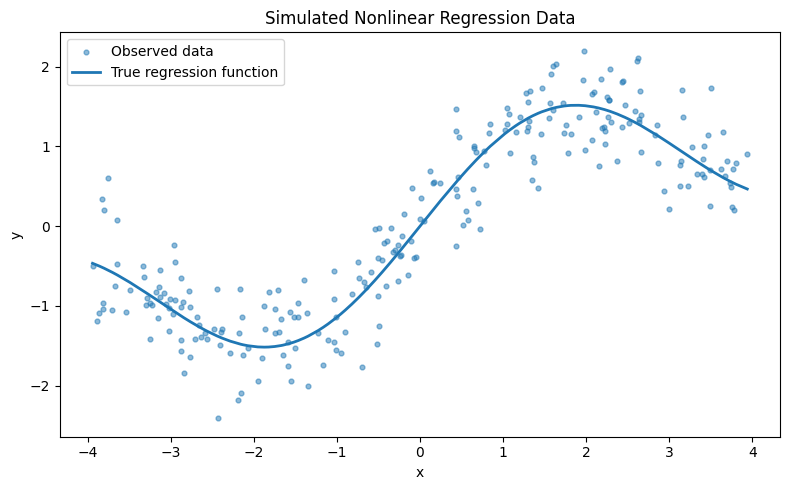

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=12, alpha=0.5, label="Observed data")
plt.plot(x, y_true, linewidth=2, label="True regression function")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simulated Nonlinear Regression Data")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/nonparametric_regression_data.png", dpi=150, bbox_inches="tight")
plt.show()

The true regression function is nonlinear. This makes the example useful for comparing rigid parametric structure with more flexible smoothing methods.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">3. Linear regression as a baseline</p>

We begin with a simple linear fit. Even when it is misspecified, linear regression is a useful baseline because of its simplicity and interpretability.

In [5]:
grid = np.linspace(x.min(), x.max(), 400)

lin_fit = fit_linear_regression_polyfit(x, y, grid)
y_hat_lin_train = np.polyval(lin_fit["coef"], x)

lin_mse = mean_squared_error_manual(y, y_hat_lin_train)

pd.DataFrame({
    "quantity": ["Train MSE"],
    "value": [lin_mse],
}).round(4)

,quantity,value
0,Train MSE,0.4881


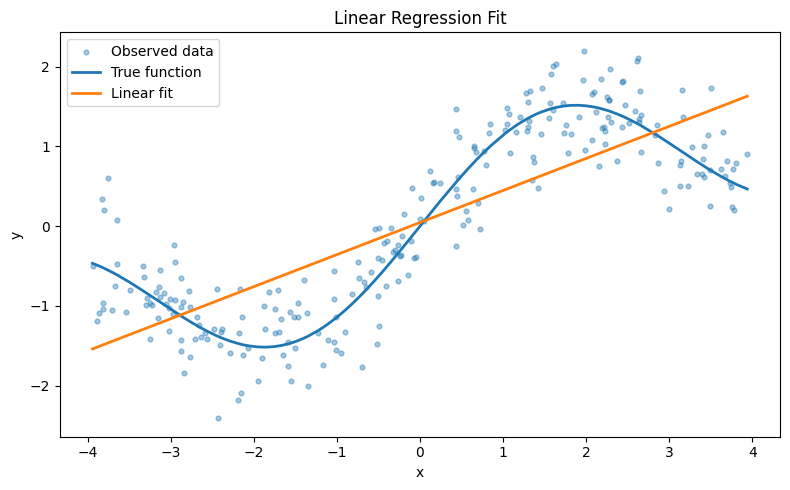

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=12, alpha=0.4, label="Observed data")
plt.plot(x, y_true, linewidth=2, label="True function")
plt.plot(grid, lin_fit["y_hat"], linewidth=2, label="Linear fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/nonparametric_regression_linear_fit.png", dpi=150, bbox_inches="tight")
plt.show()

The linear fit captures an overall trend, but it cannot recover the oscillating nonlinear structure. This is the basic motivation for nonparametric regression.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">4. LOWESS smoothing</p>

LOWESS fits local regressions around each point and stitches them together into a smooth curve.

Its key tuning parameter is `frac`, the fraction of the data used in each local neighborhood.

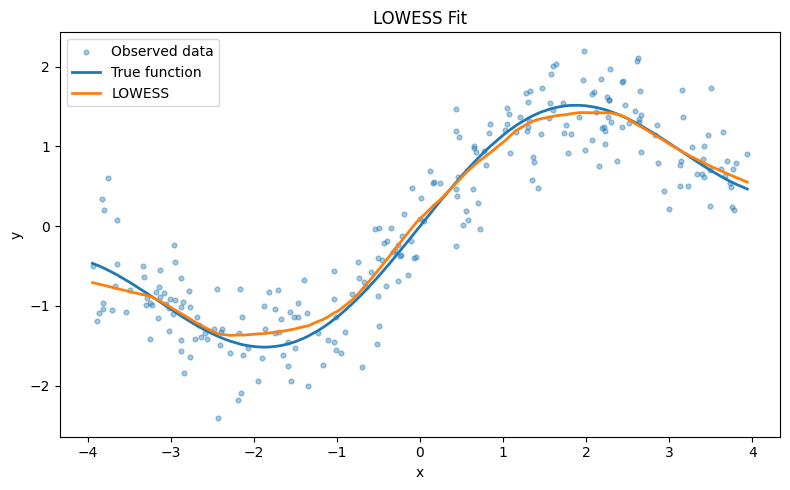

In [7]:
lowess_fit = fit_lowess(x, y, frac=0.2)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=12, alpha=0.4, label="Observed data")
plt.plot(x, y_true, linewidth=2, label="True function")
plt.plot(lowess_fit["x_sorted"], lowess_fit["y_hat"], linewidth=2, label="LOWESS")
plt.xlabel("x")
plt.ylabel("y")
plt.title("LOWESS Fit")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/nonparametric_regression_lowess_fit.png", dpi=150, bbox_inches="tight")
plt.show()

LOWESS adapts to the curvature of the data much more effectively than the linear fit. This is one of the strengths of local smoothing methods.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">5. k-NN regression</p>

k-NN regression predicts by averaging nearby observations. Its main tuning parameter is the number of neighbors.

Small $k$ gives a rough, highly local fit. Large $k$ gives a smoother but less adaptive fit.

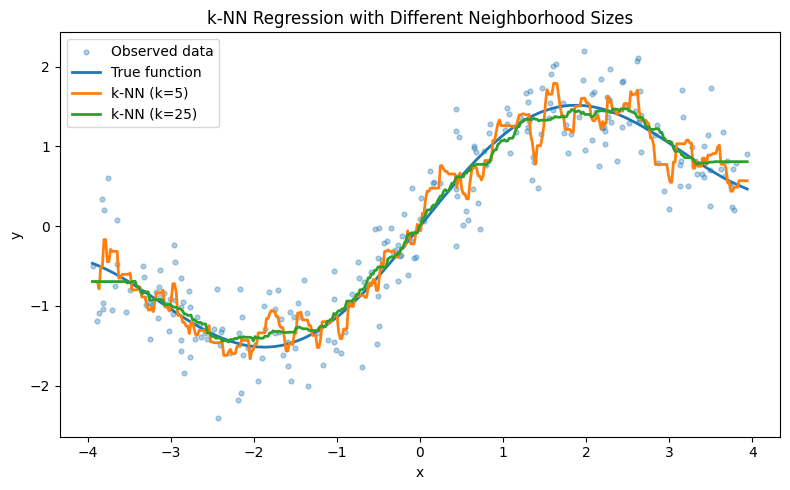

In [8]:
knn_fit_5 = fit_knn_regression(x, y, grid, n_neighbors=5)
knn_fit_25 = fit_knn_regression(x, y, grid, n_neighbors=25)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=12, alpha=0.35, label="Observed data")
plt.plot(x, y_true, linewidth=2, label="True function")
plt.plot(grid, knn_fit_5["y_hat"], linewidth=2, label="k-NN (k=5)")
plt.plot(grid, knn_fit_25["y_hat"], linewidth=2, label="k-NN (k=25)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("k-NN Regression with Different Neighborhood Sizes")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/nonparametric_regression_knn_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

This comparison makes the smoothness tradeoff very visible. Smaller neighborhoods produce a more variable fit, while larger neighborhoods produce a smoother but less locally responsive fit.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">6. Kernel regression</p>

Kernel regression uses weighted local averaging, with nearby points receiving more weight than distant points.

As in KDE, bandwidth controls the amount of smoothing.

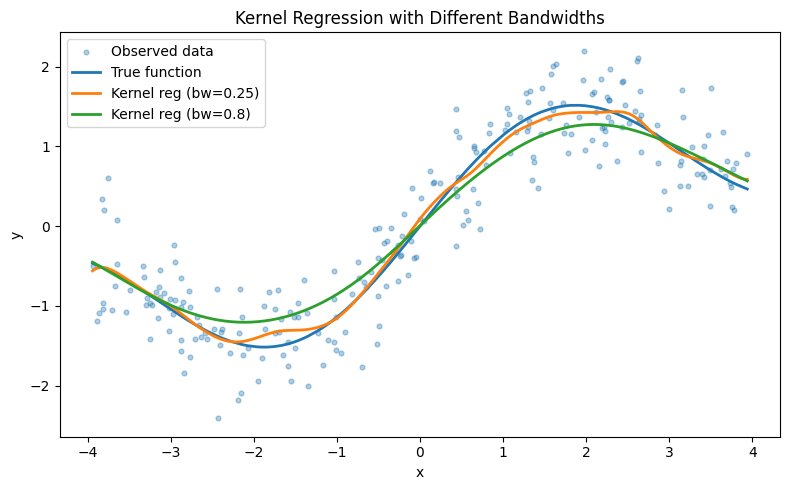

In [9]:
kr_fit_small = fit_kernel_regression(x, y, grid, bandwidth=0.25)
kr_fit_large = fit_kernel_regression(x, y, grid, bandwidth=0.8)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=12, alpha=0.35, label="Observed data")
plt.plot(x, y_true, linewidth=2, label="True function")
plt.plot(grid, kr_fit_small["y_hat"], linewidth=2, label="Kernel reg (bw=0.25)")
plt.plot(grid, kr_fit_large["y_hat"], linewidth=2, label="Kernel reg (bw=0.8)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Kernel Regression with Different Bandwidths")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/nonparametric_regression_kernel_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Kernel regression transfers the same logic seen in KDE to the regression setting. The bandwidth controls the balance between roughness and smoothness.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">7. Comparing fitted methods</p>

We now compare the fitted values on the training sample using mean squared error. This is not the whole story, but it provides a first quantitative comparison.

In [10]:
lowess_on_x = fit_lowess(x, y, frac=0.2)
knn_on_x = fit_knn_regression(x, y, x, n_neighbors=10)
kr_on_x = fit_kernel_regression(x, y, x, bandwidth=0.4)

comparison = pd.DataFrame({
    "method": ["Linear", "LOWESS", "k-NN", "Kernel regression"],
    "train_mse": [
        mean_squared_error_manual(y, np.polyval(lin_fit["coef"], x)),
        mean_squared_error_manual(y, lowess_on_x["y_hat"]),
        mean_squared_error_manual(y, knn_on_x["y_hat"]),
        mean_squared_error_manual(y, kr_on_x["y_hat"]),
    ],
})

comparison.round(4)

,method,train_mse
0,Linear,0.4881
1,LOWESS,0.1624
2,k-NN,0.1484
3,Kernel regression,0.1604


Flexible methods often fit nonlinear data better than a linear model, but this flexibility should not be confused with automatic superiority. More flexible methods can also overfit, especially if tuning parameters are chosen poorly.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">8. Strengths and limitations of nonparametric regression</p>

**Strengths**
- can capture nonlinear structure,
- avoids rigid functional-form assumptions,
- often gives a much better descriptive fit than a misspecified linear model.

**Limitations**
- requires tuning choices,
- can overfit,
- often less interpretable than simple parametric models,
- becomes harder in higher dimensions.

This is a recurring theme in nonparametric statistics: flexibility is powerful, but it demands judgment.

In [11]:
final_summary = pd.DataFrame({
    "concept": [
        "Linear regression",
        "LOWESS",
        "k-NN regression",
        "Kernel regression",
    ],
    "main feature": [
        "Rigid global functional form",
        "Local smoothing by neighborhood fraction",
        "Local averaging by nearby observations",
        "Weighted local averaging with bandwidth",
    ],
})

final_summary

,concept,main feature
0,Linear regression,Rigid global functional form
1,LOWESS,Local smoothing by neighborhood fraction
2,k-NN regression,Local averaging by nearby observations
3,Kernel regression,Weighted local averaging with bandwidth


# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">9. Takeaways</p>

This notebook introduced nonparametric regression as a flexible alternative to rigid parametric functional forms.

- Linear regression is simple and interpretable, but can be badly misspecified.
- LOWESS, k-NN regression, and kernel regression adapt to nonlinear structure.
- Tuning parameters such as neighborhood size and bandwidth control the smoothness of the fit.
- Nonparametric regression is powerful, but it does not eliminate the need for modeling judgment.

The deeper lesson is that nonparametric methods replace rigid global assumptions with local smoothing choices.